In [27]:
import pandas as pd
import numpy as np

In [28]:
llama_data = pd.read_csv('tests.csv')
flan_data = pd.read_csv('tests_flan.csv')

In [29]:
llama_data

,Unnamed: 0.1,Unnamed: 0,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent
0,0,0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'age': '20', 'name': 'anderson martins gomes'}",{},student,ADD
1,1,1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'description': 'history of', 'name': 'brazili...",{},subject,ADD
2,2,2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'_': 'br', 'age': '65', 'name': 'paulo henriq...",{},teacher,ADD
3,3,3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'description': 'the best subject ever', 'name...",{},subject,ADD
4,4,4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'description': 'best subject', 'name': 'math'}",{},subject,ADD
...,...,...,...,...,...,...,...,...,...,...,...
454,454,466,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,"{'invoice': 'with', 'value': '100'}",{},in,ADD
455,455,467,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ
456,456,468,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD
457,457,469,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD


In [30]:
flan_data

,Unnamed: 0,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent
0,0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD
1,1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD
2,2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD
3,3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD
4,4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD
...,...,...,...,...,...,...,...,...,...,...
454,466,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,{'value': '100'},{},in,ADD
455,467,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ
456,468,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD
457,469,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD


In [31]:
llama_data = llama_data.iloc[:, 2:]
llama_data

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'age': '20', 'name': 'anderson martins gomes'}",{},student,ADD
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'description': 'history of', 'name': 'brazili...",{},subject,ADD
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'_': 'br', 'age': '65', 'name': 'paulo henriq...",{},teacher,ADD
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'description': 'the best subject ever', 'name...",{},subject,ADD
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'description': 'best subject', 'name': 'math'}",{},subject,ADD
...,...,...,...,...,...,...,...,...,...
454,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,"{'invoice': 'with', 'value': '100'}",{},in,ADD
455,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ
456,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD
457,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD


In [32]:
flan_data = flan_data.iloc[: , 1:]
flan_data

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD
...,...,...,...,...,...,...,...,...,...
454,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,{'value': '100'},{},in,ADD
455,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ
456,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD
457,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD


In [33]:
flan_data['model'] = 'Flan'
flan_data

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,model
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD,Flan
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD,Flan
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD,Flan
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan
...,...,...,...,...,...,...,...,...,...,...
454,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,{'value': '100'},{},in,ADD,Flan
455,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ,Flan
456,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD,Flan
457,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD,Flan


In [34]:
llama_data['model'] = 'Llama3'
llama_data

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,model
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'age': '20', 'name': 'anderson martins gomes'}",{},student,ADD,Llama3
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'description': 'history of', 'name': 'brazili...",{},subject,ADD,Llama3
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'_': 'br', 'age': '65', 'name': 'paulo henriq...",{},teacher,ADD,Llama3
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'description': 'the best subject ever', 'name...",{},subject,ADD,Llama3
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'description': 'best subject', 'name': 'math'}",{},subject,ADD,Llama3
...,...,...,...,...,...,...,...,...,...,...
454,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,"{'invoice': 'with', 'value': '100'}",{},in,ADD,Llama3
455,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ,Llama3
456,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD,Llama3
457,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD,Llama3


In [35]:
data = pd.concat([flan_data, llama_data], axis=0, ignore_index=True)
data

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,model
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD,Flan
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD,Flan
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD,Flan
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan
...,...,...,...,...,...,...,...,...,...,...
913,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,"{'invoice': 'with', 'value': '100'}",{},in,ADD,Llama3
914,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ,Llama3
915,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD,Llama3
916,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD,Llama3


### Pós processamento dos dados

Com os testes feitos iremos tratar a tabela para realizar a análise. 

Primeiramente, para fins de obtenção de resultados, iremos passar um algoritimo que verifique quantos atributos/filters (se existirem) são requeridos em cada linha. Isso irá nos indicar até quantos atributos o sistema consegue ter uma boa precisão.

Por o dataset ainda conter diversas incoerências principalmente na questão de letras maiúsculas e minusculas, como na primeira linha na qual a mensagem possui somente letras minusculas porém em expected attributes existem letras maiúsculas, todas as linhas de processed e expected para attributes e filters serão 'normalizadas' e ficarão minúsculas.

Além disso iremos substituir os valores nulos das colunas expected attributes e expected filter por chaves vazias, para que os valores se encaixem com a resposta 'nula' da API, que são chaves vazias.

In [37]:
import ast

def count_keys(cell):
    if pd.isnull(cell): 
        return 0
    try:
        dictionary = ast.literal_eval(cell) 
        if isinstance(dictionary, dict):
            return len(dictionary.keys()) 
    except (ValueError, SyntaxError):
        return 0 
    return 0

data['total_attributes'] = data['expected_attributes'].apply(count_keys) + data['expected_filter_attributes'].apply(count_keys)
data.head(10)

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,model,total_attributes
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD,Flan,2
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD,Flan,2
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD,Flan,3
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan,2
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan,2
5,add student name=anderson,ADD,student,{'name': 'Anderson'},NaN,{'name': 'anderson'},{},student,ADD,Flan,1
6,get students with name anderson,READ,student,{'name': 'anderson'},NaN,{'name': 'anderson'},{},student,READ,Flan,1
7,show me the teachers,READ,teacher,NaN,NaN,{},{},teacher,READ,Flan,0
8,show teachers,READ,teacher,NaN,NaN,{},{},teacher,READ,Flan,0
9,show teacher,READ,teacher,NaN,NaN,{'teacher': ''},{},show,DELETE,Flan,0


In [38]:
data.expected_attributes = data.expected_attributes.str.lower()
data.expected_filter_attributes = data.expected_filter_attributes.str.lower()
data.processed_attributes = data.processed_attributes.str.lower()
data.processed_filters = data.processed_filters.str.lower()
data.head(10)

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,model,total_attributes
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'anderson martins gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD,Flan,2
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'brazilian history', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD,Flan,2
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'paulo henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD,Flan,3
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan,2
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan,2
5,add student name=anderson,ADD,student,{'name': 'anderson'},NaN,{'name': 'anderson'},{},student,ADD,Flan,1
6,get students with name anderson,READ,student,{'name': 'anderson'},NaN,{'name': 'anderson'},{},student,READ,Flan,1
7,show me the teachers,READ,teacher,NaN,NaN,{},{},teacher,READ,Flan,0
8,show teachers,READ,teacher,NaN,NaN,{},{},teacher,READ,Flan,0
9,show teacher,READ,teacher,NaN,NaN,{'teacher': ''},{},show,DELETE,Flan,0


In [39]:
data.expected_attributes = data.expected_attributes.fillna('{}')
data.expected_filter_attributes = data.expected_filter_attributes.fillna('{}')
data.head(10)

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,model,total_attributes
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'anderson martins gomes', 'age': '20'}",{},"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD,Flan,2
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'brazilian history', 'description': '...",{},"{'name': 'brazilian history', 'description': '...",{},subject,ADD,Flan,2
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'paulo henrique', 'age': '65', 'email...",{},"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD,Flan,3
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",{},"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan,2
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",{},"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,Flan,2
5,add student name=anderson,ADD,student,{'name': 'anderson'},{},{'name': 'anderson'},{},student,ADD,Flan,1
6,get students with name anderson,READ,student,{'name': 'anderson'},{},{'name': 'anderson'},{},student,READ,Flan,1
7,show me the teachers,READ,teacher,{},{},{},{},teacher,READ,Flan,0
8,show teachers,READ,teacher,{},{},{},{},teacher,READ,Flan,0
9,show teacher,READ,teacher,{},{},{'teacher': ''},{},show,DELETE,Flan,0


### Análise objetiva

Para a análise objetiva criaremos as colunas:

1. correct_intent (caso a intenção obtida seja igual à esperada, será atribuído True na coluna, caso não será atribuído False)
2. correct_entity (caso a entidade obtida seja igual à esperada, será atribuído True na coluna, caso não será atribuído False)
3. correct_attribute (caso a intenção obtida seja igual à esperada, será atribuído True na coluna, caso não será atribuído False)
4. correct_filter (caso a intenção obtida seja igual à esperada, será atribuído True na coluna, caso não será atribuído False)
5. correct_answer (caso todas as colunas anteriores sinalizem True, esta será True, caso não, será False)

Com isso iremos extrair:

1. Quantidade de acertos para cada dado
2. Quantidade de acertos totais
3. Precisão de acertos para cada dado
4. Precisão de acertos totais
5. Quantidade de acertos para cada operação CRUD
6. Precisão para cada operação CRUD
7. Quantidade de acertos para cada dado e para cada operação CRUD
8. Precisão para cada dado e para cada operação CRUD
9. Precisão para cada número de atributos
10. Precisão de cada dado para cada número de atributos


In [41]:
objective_analysis = pd.DataFrame()
objective_analysis['user_msg'] = data.user_msg
objective_analysis['intent'] = data.expected_intent
objective_analysis['att_qnt'] = data.total_attributes
objective_analysis['model'] = data.model
objective_analysis['correct_intent'] = data.expected_intent == data.find_intent
objective_analysis['correct_entity'] = data.expected_class == data.find_entity
objective_analysis['correct_attributes'] = data.expected_attributes == data.processed_attributes
objective_analysis['correct_filters'] = data.expected_filter_attributes == data.processed_filters
objective_analysis['correct_answer'] = objective_analysis.correct_intent & objective_analysis.correct_entity & objective_analysis.correct_attributes & objective_analysis.correct_filters
objective_analysis.head(10)


,user_msg,intent,att_qnt,model,correct_intent,correct_entity,correct_attributes,correct_filters,correct_answer
0,"add student with name=anderson martins gomes, ...",ADD,2,Flan,True,True,True,True,True
1,"add subject with name=brazilian history, descr...",ADD,2,Flan,True,True,True,True,True
2,"add teacher with name=paulo henrique, age=65, ...",ADD,3,Flan,True,True,False,True,False
3,"add subject with name=math, description=the be...",ADD,2,Flan,True,True,True,True,True
4,"add subject with name=math, description='the b...",ADD,2,Flan,True,True,True,True,True
5,add student name=anderson,ADD,1,Flan,True,True,True,True,True
6,get students with name anderson,READ,1,Flan,True,True,True,True,True
7,show me the teachers,READ,0,Flan,True,True,True,True,True
8,show teachers,READ,0,Flan,True,True,True,True,True
9,show teacher,READ,0,Flan,False,False,False,True,False


In [42]:
cor_intent = objective_analysis['correct_intent'].sum()
cor_entity = objective_analysis['correct_entity'].sum()
cor_att = objective_analysis['correct_attributes'].sum()
cor_filter = objective_analysis['correct_filters'].sum()
cor_total = objective_analysis['correct_answer'].sum()

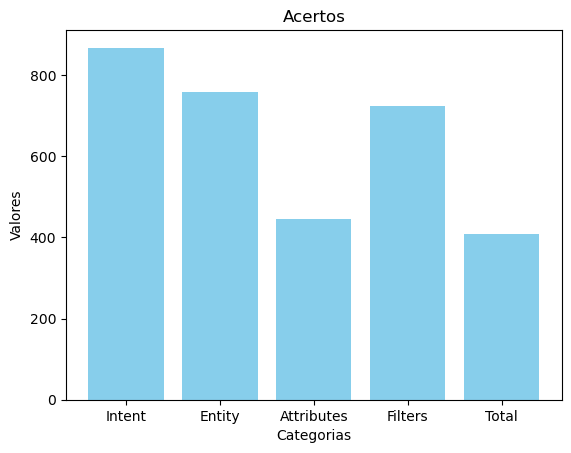

In [43]:
import matplotlib.pyplot as plt

plt.bar(['Intent', 'Entity', 'Attributes', 'Filters', 'Total'], [cor_intent, cor_entity, cor_att, cor_filter, cor_total], color='skyblue')

plt.title('Acertos')
plt.xlabel('Categorias')
plt.ylabel('Valores')

plt.show()

### Acertos por quantidade de atributos
Agora que extraimos os acertos para cada tipo de dado iremos verificar os acertos para cada quantidade de atributos (filtros + atributos).
Iremos primeiro verificar a variação de quantidade de atributos e em seguida verificar quantos 'true' cada variação obtem.

In [45]:
result = objective_analysis.groupby('att_qnt')['correct_answer'].sum().reset_index()
result.columns = ['att_qnt', 'correct_answer']
print(result)

   att_qnt  correct_answer
0        0             131
1        1             192
2        2              82
3        3               1
4        4               2
5        5               1
6        7               0


Como o número de linhas para cada att_qnt varia (ex: existe apenas uma linha com 7 atributos enquanto com 0 existem 109), iremos extrair informações mais reveladoras se levarmos em conta a porcentagem de acertos (casos_certos/casos_totais)

In [47]:
total_counts = objective_analysis['att_qnt'].value_counts().reset_index()
total_counts.columns = ['att_qnt', 'total_count']

result_percentage = pd.merge(result, total_counts, on='att_qnt')

result_percentage['accuracy_percentage'] = (result_percentage['correct_answer'] / result_percentage['total_count']) * 100

print(result_percentage)

   att_qnt  correct_answer  total_count  accuracy_percentage
0        0             131          218            60.091743
1        1             192          322            59.627329
2        2              82          320            25.625000
3        3               1           34             2.941176
4        4               2           16            12.500000
5        5               1            6            16.666667
6        7               0            2             0.000000


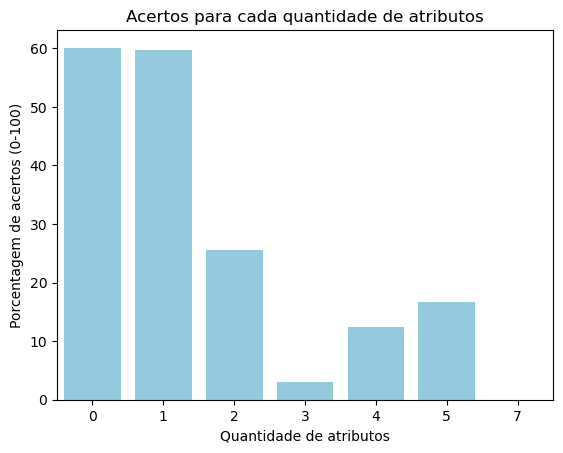

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=result_percentage, x='att_qnt', y='accuracy_percentage', color='skyblue')

plt.title('Acertos para cada quantidade de atributos')
plt.xlabel('Quantidade de atributos')
plt.ylabel('Porcentagem de acertos (0-100)')

plt.show()

### Fazendo o mesmo para cada operação crud

In [50]:
objective_analysis.intent.value_counts()

intent
ADD       338
READ      286
UPDATE    198
DELETE     96
Name: count, dtype: int64

In [51]:
result_intent = objective_analysis.groupby('intent')['correct_answer'].sum().reset_index()
result_intent.columns = ['intent', 'correct_answer']
print(result_intent)

   intent  correct_answer
0     ADD             141
1  DELETE              56
2    READ             173
3  UPDATE              39


In [52]:
total_counts_intent = objective_analysis['intent'].value_counts().reset_index()
total_counts_intent.columns = ['intent', 'total_count']
result_intent_percentage = pd.merge(result_intent, total_counts_intent, on='intent')
result_intent_percentage['accuracy_percentage'] = (result_intent_percentage['correct_answer'] / result_intent_percentage['total_count']) * 100
print(result_intent_percentage)

   intent  correct_answer  total_count  accuracy_percentage
0     ADD             141          338            41.715976
1  DELETE              56           96            58.333333
2    READ             173          286            60.489510
3  UPDATE              39          198            19.696970


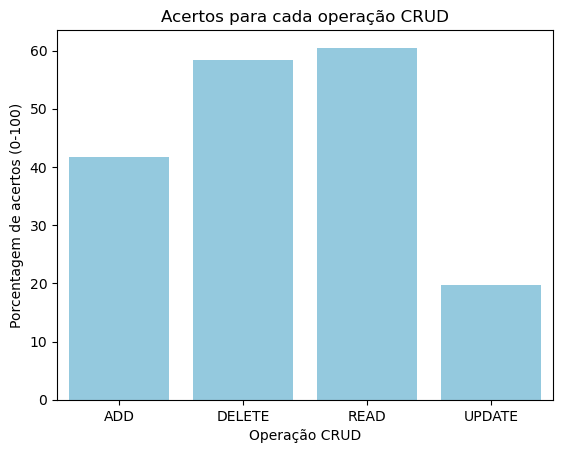

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=result_intent_percentage, x='intent', y='accuracy_percentage', color='skyblue')

plt.title('Acertos para cada operação CRUD')
plt.xlabel('Operação CRUD')
plt.ylabel('Porcentagem de acertos (0-100)')

plt.show()

### Precisão de acertos para cada tipo de dado

Agora iremos analisar o quanto a operação CRUD interferiu na precisão de cada tipo de dado (intent, entity, attribute e filter)
Faremos isso também para quantidade de atributos.

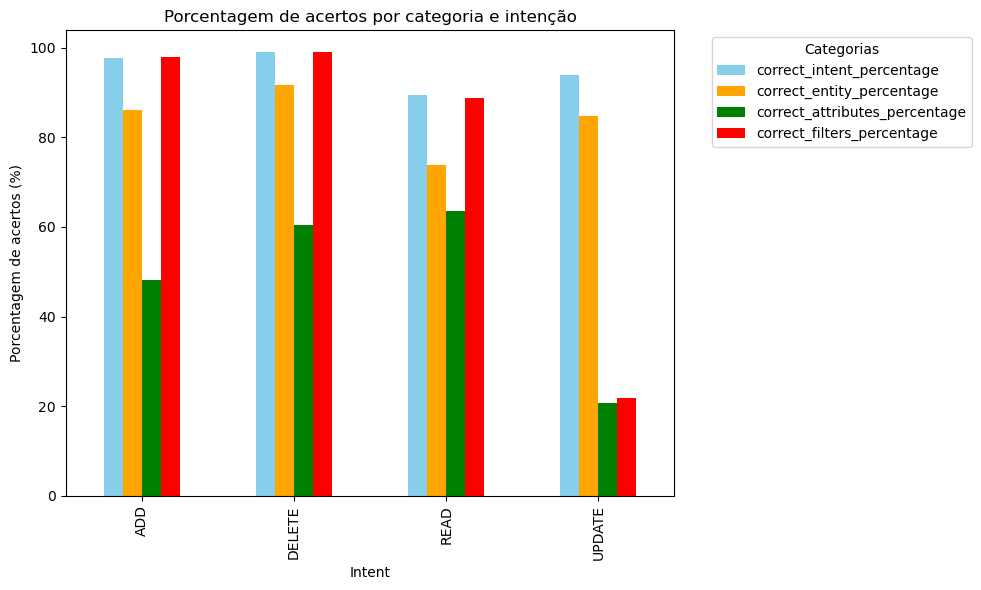

In [55]:
intent_totals = objective_analysis.groupby("intent").size().reset_index(name="total_count")

columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
grouped_data = objective_analysis.groupby("intent")[columns_to_count].sum().reset_index()

grouped_data = pd.merge(grouped_data, intent_totals, on="intent")
for col in columns_to_count:
    grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100

percentage_columns = [f"{col}_percentage" for col in columns_to_count]
plot_data = grouped_data.set_index("intent")[percentage_columns]

plot_data.plot(kind="bar", figsize=(10, 6), stacked=False, color=["skyblue", "orange", "green", "red"])

plt.title("Porcentagem de acertos por categoria e intenção")
plt.xlabel("Intent")
plt.ylabel("Porcentagem de acertos (%)")
plt.legend(title="Categorias", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

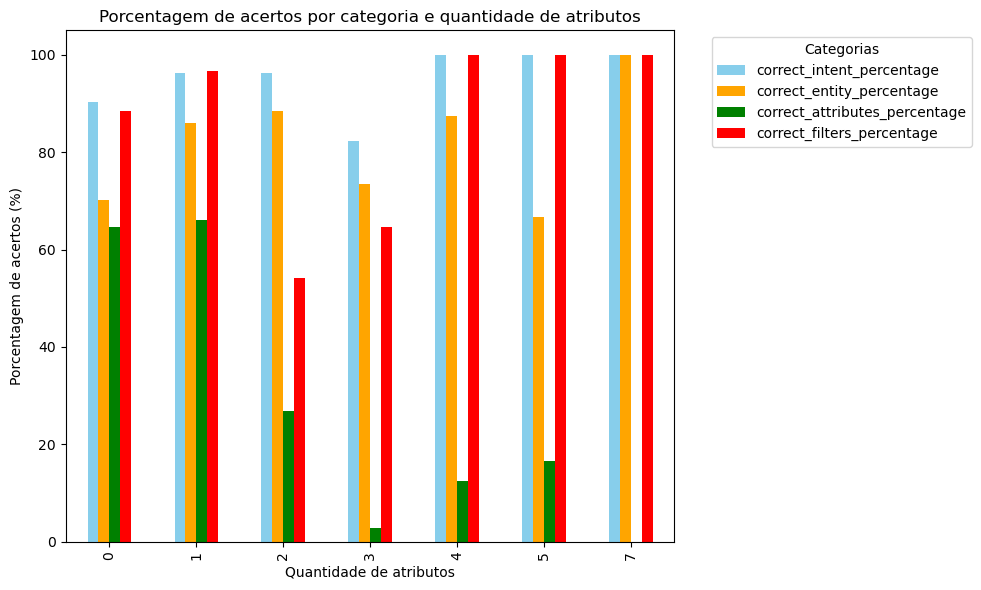

In [56]:
att_totals = objective_analysis.groupby("att_qnt").size().reset_index(name="total_count")

columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
grouped_data = objective_analysis.groupby("att_qnt")[columns_to_count].sum().reset_index()
grouped_data = pd.merge(grouped_data, att_totals, on="att_qnt")
for col in columns_to_count:
    grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100
percentage_columns = [f"{col}_percentage" for col in columns_to_count]
plot_data = grouped_data.set_index("att_qnt")[percentage_columns]

plot_data.plot(kind="bar", figsize=(10, 6), stacked=False, color=["skyblue", "orange", "green", "red"])

plt.title("Porcentagem de acertos por categoria e quantidade de atributos")
plt.xlabel("Quantidade de atributos")
plt.ylabel("Porcentagem de acertos (%)")
plt.legend(title="Categorias", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Fazendo o mesmo para cada modelo de LLM

In [58]:
objective_analysis.model.value_counts()

model
Flan      459
Llama3    459
Name: count, dtype: int64

In [59]:
result_model = objective_analysis.groupby('model')['correct_answer'].sum().reset_index()
result_model.columns = ['model', 'correct_answer']
print(result_model)

    model  correct_answer
0    Flan             229
1  Llama3             180


In [60]:
total_counts_model = objective_analysis['model'].value_counts().reset_index()
total_counts_model.columns = ['model', 'total_count']
result_model_percentage = pd.merge(result_model, total_counts_model, on='model')
result_model_percentage['accuracy_percentage'] = (result_model_percentage['correct_answer'] / result_model_percentage['total_count']) * 100
print(result_model_percentage)

    model  correct_answer  total_count  accuracy_percentage
0    Flan             229          459            49.891068
1  Llama3             180          459            39.215686


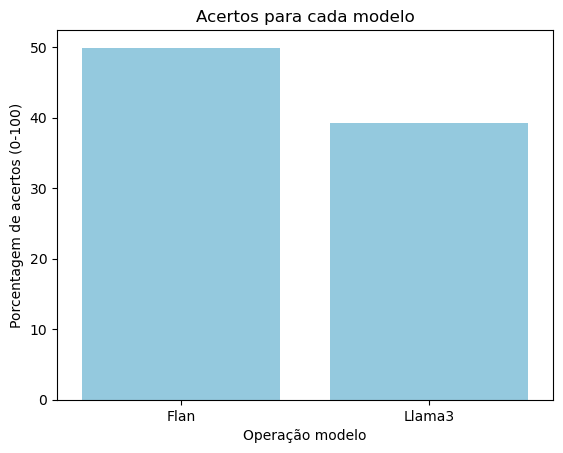

In [61]:
sns.barplot(data=result_model_percentage, x='model', y='accuracy_percentage', color='skyblue')

plt.title('Acertos para cada modelo')
plt.xlabel('Operação modelo')
plt.ylabel('Porcentagem de acertos (0-100)')

plt.show()

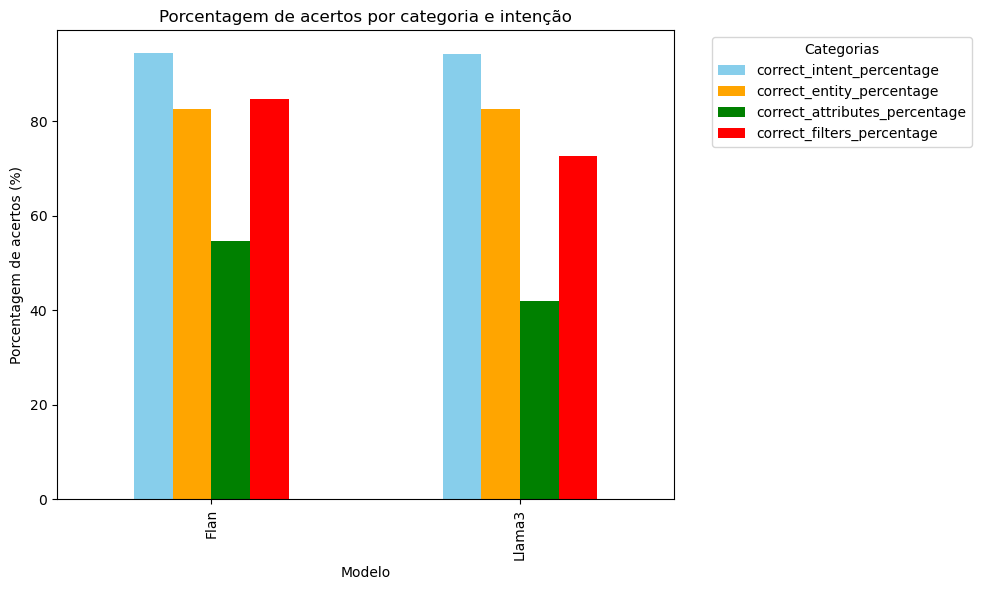

In [62]:
model_totals = objective_analysis.groupby("model").size().reset_index(name="total_count")

columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
grouped_data = objective_analysis.groupby("model")[columns_to_count].sum().reset_index()

grouped_data = pd.merge(grouped_data, model_totals, on="model")
for col in columns_to_count:
    grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100

percentage_columns = [f"{col}_percentage" for col in columns_to_count]
plot_data = grouped_data.set_index("model")[percentage_columns]

plot_data.plot(kind="bar", figsize=(10, 6), stacked=False, color=["skyblue", "orange", "green", "red"])

plt.title("Porcentagem de acertos por categoria e intenção")
plt.xlabel("Modelo")
plt.ylabel("Porcentagem de acertos (%)")
plt.legend(title="Categorias", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()